# Detecting Topic Merges and Splits in Dynamic Political Conversations

Cláudia Oliveira

Supervisor - Prof. Dr. Álvaro Figueira

Faculty of Science, University of Porto

### Instalations

In [1]:
%%capture
!pip install  sentence-transformers  gensim scikit-learn pandas  tqdm emoji rapidfuzz nltk
import nltk
nltk.download('stopwords')
!pip install -U numpy==1.26.4
!pip install -U scipy==1.11.4
!pip install -U hdbscan==0.8.33
!pip install -U bertopic==0.16.0

### Importing necessary packages

In [ ]:
import pandas as pd
import numpy as np
import random
import ast
import torch
from datetime import timedelta
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from sklearn.metrics.pairwise import cosine_similarity
import pickle

In [3]:
from google.colab import files
uploaded = files.upload()

Saving window_topics.pkl to window_topics.pkl


### Topic Modeling with Sliding Window

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

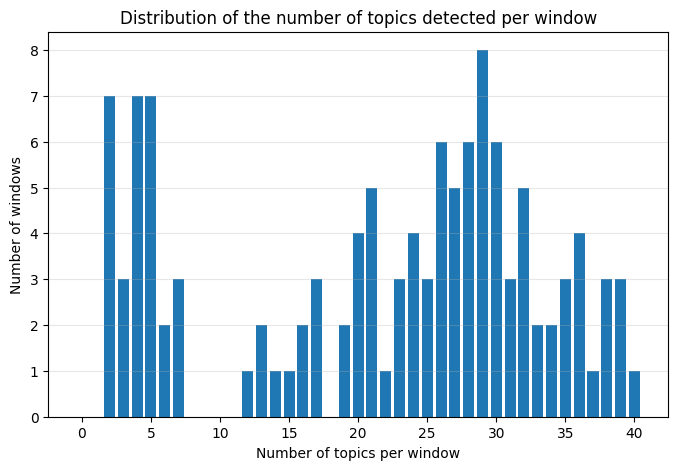

In [ ]:
# ============================================================================================================================================================
# 1. CONFIGURATION
# ============================================================================================================================================================
window_size = timedelta(days=7)
step_size = timedelta(days=3)
min_docs_per_topic = 50
top_n_words = 10

# SentenceTransformer embeddings
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

# Vectorizer for BERTopic
vectorizer_model = CountVectorizer(max_features=170_000)

# HDBSCAN configuration
hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    metric='euclidean'
)

# ============================================================================================================================================================
# 2. LOAD DATA
# ============================================================================================================================================================
tweets = pd.read_csv("cleanedtweets.csv", encoding="utf-8", low_memory=False)
tweets = tweets[['doc_id', 'created_at', 'tokens', 'text_original']].copy()
tweets['created_at'] = pd.to_datetime(tweets['created_at'])
tweets = tweets.sort_values('created_at')

# Convert token strings to lists
tweets['tokens'] = tweets['tokens'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

tweets = tweets[tweets['tokens'].notnull()].reset_index(drop=True)

# ============================================================================================================================================================
# 3. WINDOW-BASED PROCESSING
# ============================================================================================================================================================
start = tweets['created_at'].min()
end = tweets['created_at'].max()
current = start

window_topics = []

while current + window_size < end:
    current_end = current + window_size
    subset = tweets[(tweets['created_at'] >= current) & (tweets['created_at'] < current_end)]

    if len(subset) < 10:
        current += step_size
        continue

    docs_window = [" ".join(tokens) for tokens in subset['tokens']]
    if len(docs_window) == 0:
        current += step_size
        continue

    # ====================================================
    # BERTopic
    # ====================================================
    topic_model = BERTopic(
        embedding_model=None,
        umap_model=None,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        calculate_probabilities=False,
        verbose=False
    )

    embeddings = embedding_model.encode(docs_window)
    topics, _ = topic_model.fit_transform(docs_window, embeddings=embeddings)

    subset = subset.copy()
    subset["topic_id"] = topics
    subset["embedding"] = list(embeddings)

    # Filter topics with no documents
    topic_info = topic_model.get_topic_info()
    valid_topics = topic_info[topic_info["Count"] >= min_docs_per_topic]["Topic"].tolist()

    # Topic → words
    topic_words_dict = {
        tid: [w for w, _ in topic_model.get_topic(tid)[:top_n_words]]
        for tid in valid_topics
    }

    # Topic document counts
    topic_doc_counts = {
        int(row["Topic"]): int(row["Count"])
        for _, row in topic_info.iterrows()
        if row["Topic"] in valid_topics
    }

    # Topic embeddings
    topic_embeddings = {}

    for tid in valid_topics:
        docs_topic = subset[subset["topic_id"] == tid]

        if len(docs_topic) == 0:
            continue

        topic_embs = np.vstack(docs_topic["embedding"].values)
        centroid = topic_embs.mean(axis=0)
        topic_embeddings[tid] = centroid

    window_topics.append({
        "start_date": current,
        "end_date": current_end,
        "num_docs": len(subset),
        "topic_words": topic_words_dict,
        "topic_embeddings": topic_embeddings,
        "topic_doc_counts": topic_doc_counts,
        "tweets_with_topics": subset[[
            "doc_id",
            "created_at",
            "tokens",
            "text_original",
            "topic_id",
            "embedding"
        ]].to_dict(orient="records")
    })

    current += step_size

with open("window_topics.pkl", "wb") as f:
    pickle.dump(window_topics, f)

# ============================================================================================================================================================
# 4. Histogram of topics per window
# ============================================================================================================================================================

num_topics_per_window = [len(w["topic_words"]) for w in window_topics]

plt.figure(figsize=(8,5))
plt.hist(num_topics_per_window, bins=range(0, max(num_topics_per_window)+2), align='left', rwidth=0.8)
plt.xlabel("Number of topics per window")
plt.ylabel("Number of windows")
plt.title("Distribution of the number of topics detected per window")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [11]:
import pickle
import pandas as pd
import numpy as np
import random
import ast
import torch
from datetime import timedelta
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
with open("datasets/.pkl/window_topics.pkl", "rb") as f:
    window_topics = pickle.load(f)

In [17]:
relations = []

tweet_to_centroid_threshold = 0.4
similarity_threshold = 0.7
coverage_threshold_forward = 0.3
coverage_threshold_backward = 0.3

In [14]:
def compute_coverage_forward(w1, w2):
    coverages = {}
    w1_docs = pd.DataFrame(w1["tweets_with_topics"])
    w2_docs = pd.DataFrame(w2["tweets_with_topics"])
    w1_docs = w1_docs[w1_docs["topic_id"] != -1]
    w2_docs = w2_docs[w2_docs["topic_id"] != -1]

    t2_ids = [tid for tid in w2["topic_embeddings"].keys() if tid != -1]
    centroids_new = np.array([w2["topic_embeddings"][tid] for tid in t2_ids])

    for tid1 in [tid for tid in w1["topic_embeddings"].keys() if tid != -1]:
        docs_t1 = w1_docs[w1_docs["topic_id"] == tid1]
        if docs_t1.empty:
            continue
        tweet_embs = np.vstack(docs_t1["embedding"].values)
        sim_matrix = cosine_similarity(tweet_embs, centroids_new)
        best_matches = sim_matrix.argmax(axis=1)
        best_scores = sim_matrix.max(axis=1)
        valid_idx = best_scores >= tweet_to_centroid_threshold
        best_matches = best_matches[valid_idx]
        counts_by_idx = np.bincount(best_matches, minlength=len(t2_ids))
        total_old = len(tweet_embs)
        for idx2, cnt in enumerate(counts_by_idx):
            if cnt > 0:
                coverages[(tid1, t2_ids[idx2])] = cnt / total_old
    return coverages

def compute_coverage_backward(w1, w2):
    coverages = {}
    w1_docs = pd.DataFrame(w1["tweets_with_topics"])
    w2_docs = pd.DataFrame(w2["tweets_with_topics"])
    w1_docs = w1_docs[w1_docs["topic_id"] != -1]
    w2_docs = w2_docs[w2_docs["topic_id"] != -1]

    t1_ids = [tid for tid in w1["topic_embeddings"].keys() if tid != -1]
    centroids_old = np.array([w1["topic_embeddings"][tid] for tid in t1_ids])

    for tid2 in [tid for tid in w2["topic_embeddings"].keys() if tid != -1]:
        docs_t2 = w2_docs[w2_docs["topic_id"] == tid2]
        if docs_t2.empty:
            continue
        tweet_embs = np.vstack(docs_t2["embedding"].values)
        sim_matrix = cosine_similarity(tweet_embs, centroids_old)
        best_matches = sim_matrix.argmax(axis=1)
        best_scores = sim_matrix.max(axis=1)
        valid_idx = best_scores >= tweet_to_centroid_threshold
        best_matches = best_matches[valid_idx]
        counts_by_idx = np.bincount(best_matches, minlength=len(t1_ids))
        total_new = len(tweet_embs)
        for idx1, cnt in enumerate(counts_by_idx):
            if cnt > 0:
                coverages[(t1_ids[idx1], tid2)] = cnt / total_new
    return coverages

In [18]:
# ============================================================================================================================================================
# Main Loop w1 → w2
# ============================================================================================================================================================

for i in range(len(window_topics)-1):
    w1, w2 = window_topics[i], window_topics[i+1]
    if not w1["topic_embeddings"] or not w2["topic_embeddings"]:
        continue

    t1_ids = [tid for tid in w1["topic_embeddings"].keys() if tid != -1]
    t2_ids = [tid for tid in w2["topic_embeddings"].keys() if tid != -1]
    emb1 = np.array([w1["topic_embeddings"][tid] for tid in t1_ids])
    emb2 = np.array([w2["topic_embeddings"][tid] for tid in t2_ids])

    sim_matrix = cosine_similarity(emb1, emb2)

    coverage_f = compute_coverage_forward(w1, w2)
    coverage_b = compute_coverage_backward(w1, w2)

    # Relations: continued, split, disappeared
    for idx1, tid1 in enumerate(t1_ids):
        sims = sim_matrix[idx1]
        connected = [
            t2_ids[idx2]
            for idx2, sim in enumerate(sims)
            if sim >= similarity_threshold
            and coverage_f.get((tid1, t2_ids[idx2]), 0) >= coverage_threshold_forward
            and coverage_b.get((tid1, t2_ids[idx2]), 0) >= coverage_threshold_backward
        ]
        cover_f_vals = [coverage_f.get((tid1,t2),0) for t2 in connected]
        cover_b_vals = [coverage_b.get((tid1,t2),0) for t2 in connected]
        total_f = sum(cover_f_vals)
        total_b = sum(cover_b_vals)

        if not connected or total_f < 0.4 or total_b < 0.4:
            relation = "disappeared"
        elif len(connected)==1 and cover_f_vals[0]>0.5 and cover_b_vals[0]>0.5 and sims[t2_ids.index(connected[0])]>0.9:
            relation = "continued"
        elif len(connected)>=2 and total_f>=0.7 and all(cv>0.5 for cv in cover_b_vals):
            relation = "split"
        else:
            relation = "unclear"

        relations.append({
            "window1": i,
            "topic1": tid1,
            "topic1_words": w1["topic_words"].get(tid1, []),
            "window2": i+1,
            "successors": connected,
            "successors_words": [w2["topic_words"].get(t2, []) for t2 in connected],
            "successors_similarities": [round(sims[t2_ids.index(t2)],3) for t2 in connected],
            "coverage_forward": [round(cv,3) for cv in cover_f_vals],
            "coverage_backward": [round(cv,3) for cv in cover_b_vals],
            "coverage_sum_forward": round(total_f,3),
            "coverage_sum_backward": round(total_b,3),
            "relation": relation
        })

    # Merge detection
    for idx2, tid2 in enumerate(t2_ids):
        sims = sim_matrix[:, idx2]
        connected2 = [
            t1_ids[idx1]
            for idx1, sim in enumerate(sims)
            if sim >= similarity_threshold
            and coverage_f.get((t1_ids[idx1], tid2), 0) >= coverage_threshold_forward
            and coverage_b.get((t1_ids[idx1], tid2), 0) >= coverage_threshold_backward
        ]
        cover_f_vals = [coverage_f.get((t1,t2_ids[idx2]),0) for t1 in connected2]
        cover_b_vals = [coverage_b.get((t1,t2_ids[idx2]),0) for t1 in connected2]
        total_f = sum(cover_f_vals)
        total_b = sum(cover_b_vals)

        if len(connected2)>=2 and total_b>=0.7 and all(cv>0.5 for cv in cover_f_vals):
            relations.append({
                "window1": i,
                "topics_from": connected2,
                "topics_from_words": [w1["topic_words"].get(tid,[]) for tid in connected2],
                "window2": i+1,
                "topic_to": tid2,
                "topic_to_words": w2["topic_words"].get(tid2,[]),
                "antecedents_similarities": [round(sim_matrix[t1_ids.index(tid), idx2],3) for tid in connected2],
                "coverage_forward": [round(cv,3) for cv in cover_f_vals],
                "coverage_backward": [round(cv,3) for cv in cover_b_vals],
                "coverage_sum_forward": round(total_f,3),
                "coverage_sum_backward": round(total_b,3),
                "relation": "merge"
            })

# Remove false positives
merged_from_pairs = set()
for r in relations:
    if r.get("relation")=="merge":
        merged_from_pairs.update([(r["window1"], tid) for tid in r["topics_from"]])

relations = [
    r for r in relations
    if not (
        r["relation"] in ["disappeared","unclear", "continued"] and (r["window1"], r.get("topic1",-1)) in merged_from_pairs
    )
]

df_final_relations = pd.DataFrame(relations)

In [19]:
df_final_relations["relation"].value_counts()

relation
continued      1391
disappeared     817
unclear         117
merge            38
split            37
Name: count, dtype: int64

In [ ]:
def compute_tq_slice(topic_words_dict, docs, dictionary, top_n=10):

    topic_words = [words[:top_n] for words in topic_words_dict.values() if words]
    if not topic_words:
        return None, None, None, None, None

    texts = [doc.split() for doc in docs]

    # ---- Coherence Models ----

    cm_cv = CoherenceModel(
        topics=topic_words,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    cm_npmi = CoherenceModel(
        topics=topic_words,
        texts=texts,
        dictionary=dictionary,
        coherence='c_npmi'
    )

    cm_umass = CoherenceModel(
        topics=topic_words,
        texts=texts,
        dictionary=dictionary,
        coherence='u_mass'
    )

    cv_scores = cm_cv.get_coherence_per_topic()
    npmi_scores = cm_npmi.get_coherence_per_topic()
    umass_scores = cm_umass.get_coherence_per_topic()

    # ---- Diversity ----

    K = len(topic_words)
    diversities = []
    for k, words_k in enumerate(topic_words):
        overlaps = 0
        for i, words_j in enumerate(topic_words):
            if i == k:
                continue
            overlaps += len(set(words_k) & set(words_j)) / len(words_k)
        redundancy = overlaps / (K - 1) if K > 1 else 0
        diversities.append(1 - redundancy)

    # ---- TQ ----

    tq = np.mean([c * d for c, d in zip(cv_scores, diversities)])

    return (
        tq,
        np.mean(cv_scores),
        np.mean(diversities),
        np.mean(npmi_scores),
        np.mean(umass_scores)
    )

In [ ]:
dictionary = Dictionary([doc.split() for doc in [" ".join(tokens) for tokens in tweets["tokens"]]])

final_rows = []

for w in window_topics:

    window_docs = [" ".join(item["tokens"]) for item in w["tweets_with_topics"]]

    valid_topics = dict(sorted(
        ((tid, words) for tid, words in w["topic_words"].items() if len(words) > 0),
        key=lambda x: x[0]
    ))

    tq, cv, diversity, npmi, umass = compute_tq_slice(
        valid_topics,
        window_docs,
        dictionary,
        top_n=top_n_words
    )

    topic_strings = [" | ".join(words) for words in valid_topics.values()]
    topic_counts_list = [w["topic_doc_counts"].get(tid, 0) for tid in valid_topics.keys()]

    final_rows.append({
        "start_date": w["start_date"],
        "end_date": w["end_date"],
        "num_docs": w["num_docs"],
        "cv": cv,
        "npmi": npmi,
        "umass": umass,
        "diversity": diversity,
        "tq": tq,
        "topics": topic_strings,
        "topic_doc_counts": topic_counts_list
    })

df_final = pd.DataFrame(final_rows)

In [ ]:
rows = []

for i, window in enumerate(window_topics):
    start_date = window["start_date"]
    end_date = window["end_date"]
    topic_words = window["topic_words"]
    topic_doc_counts = window["topic_doc_counts"]

    tweets_data = pd.DataFrame(window["tweets_with_topics"])

    for topic_id, words in topic_words.items():
        if topic_id == -1:
            continue

        num_docs = topic_doc_counts.get(topic_id, 0)

        topic_tweets = tweets_data[tweets_data["topic_id"] == topic_id]

        if len(topic_tweets) > 0:
            sampled_tweets = topic_tweets.sample(
                n=min(5, len(topic_tweets)),
                random_state=42
            )["text_original"].tolist()
        else:
            sampled_tweets = []

        top_tweets_str = " | ".join(sampled_tweets)

        rows.append({
            "window_id": i,
            "topic_id": topic_id,
            "start_date": start_date,
            "end_date": end_date,
            "num_docs": num_docs,
            "words": ", ".join(words[:10]),
            "top_tweets": top_tweets_str
        })

df_topics = pd.DataFrame(rows, columns=[
    "window_id", "topic_id", "start_date", "end_date", "num_docs", "words", "top_tweets"
])

df_grouped = (
    df_topics.groupby(["window_id", "start_date", "end_date"], sort=False)
    .agg({
        "num_docs": lambda x: list(x),
        "words": lambda x: str([w.replace(", ", "|") for w in x]),
        "top_tweets": lambda x: str([t.replace(" | ", "||") for t in x])
    })
    .reset_index()
    .rename(columns={
        "num_docs": "topic_doc_counts",
        "words": "topics",
        "top_tweets": "representative_tweets"
    })
)

df_grouped.head()

,window_id,start_date,end_date,topic_doc_counts,topics,representative_tweets
0,0,2024-09-26 00:00:01,2024-10-03 00:00:01,"[4451, 517, 159, 150, 118, 65]",['kamala|community|help|helene|work|family|har...,"['As a member of the @ProChoiceCaucus, my coll..."
1,1,2024-09-29 00:00:01,2024-10-06 00:00:01,"[1303, 732, 663, 435, 256, 216, 167, 115, 95, ...",['community|great|work|service|help|thank|supp...,"[""Excited to announce our newest spooky advent..."
2,2,2024-10-02 00:00:01,2024-10-09 00:00:01,"[899, 535, 464, 401, 250, 203, 194, 122, 112, ...",['israel|attack|hamas|hostage|terrorist|one|ye...,"[""One year ago, Hamas committed one of the mos..."
3,3,2024-10-05 00:00:01,2024-10-12 00:00:01,"[4521, 777, 153, 67]",['kamala|hurricane|federal|help|community|need...,"['After botching the Afghanistan withdrawal, H..."
4,4,2024-10-08 00:00:01,2024-10-15 00:00:01,"[973, 526, 233, 206, 176, 139, 137, 129, 97, 9...",['hurricane|milton|emergency|federal|managemen...,"[""@FCC Read the full letter to @JRosenworcel ..."


In [ ]:
df_grouped.to_csv("bertilda.csv", index=False)
df_final_relations.to_csv("bertilda_mergeandsplits.csv", index=False)
df_final.to_csv("bertildaresults.csv", index=False)